In [2]:
import numpy as np
print(np.__version__)

2.5.3


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'matplotlib'

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", plt.matplotlib.__version__)

ModuleNotFoundError: No module named 'matplotlib'

In [6]:
import sys
print(sys.executable)

c:\Users\icecr\AppData\Local\Programs\Python\Python313\python.exe


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", plt.matplotlib.__version__)

NumPy: 2.5.3
Pandas: 3.0.6
Matplotlib: 3.11.2


In [8]:
rain = pd.Series([
    47, 44, 38, 43, 60, 78,
    88, 70, 48, 41, 47, 50
])

print("Місто: Київ")
print("Місячні опади, мм:")
print(rain)

Місто: Київ
Місячні опади, мм:
0     47
1     44
2     38
3     43
4     60
5     78
6     88
7     70
8     48
9     41
10    47
11    50
dtype: int64


In [11]:
variation_series = np.sort(rain.values)

print(variation_series)

[38 41 43 44 47 47 48 50 60 70 78 88]


In [12]:
bins = [35, 50, 65, 80, 90]

freq = pd.cut(rain, bins=bins, right=False).value_counts().sort_index()
rel = (freq / len(rain) * 100).round(1)
cum = freq.cumsum()

frequency_table = pd.DataFrame({
    "Абсолютна частота": freq,
    "Відносна частота, %": rel,
    "Накопичена частота": cum
})

frequency_table

,Абсолютна частота,"Відносна частота, %",Накопичена частота
"[35, 50)",7,58.3,7
"[50, 65)",2,16.7,9
"[65, 80)",2,16.7,11
"[80, 90)",1,8.3,12


In [13]:
third_boundary = 80
count_to_boundary = (rain <= third_boundary).sum()
fraction = count_to_boundary / len(rain)

print("Кількість місяців:", count_to_boundary)
print("Частка місяців:", round(fraction * 100, 1), "%")

Кількість місяців: 11
Частка місяців: 91.7 %


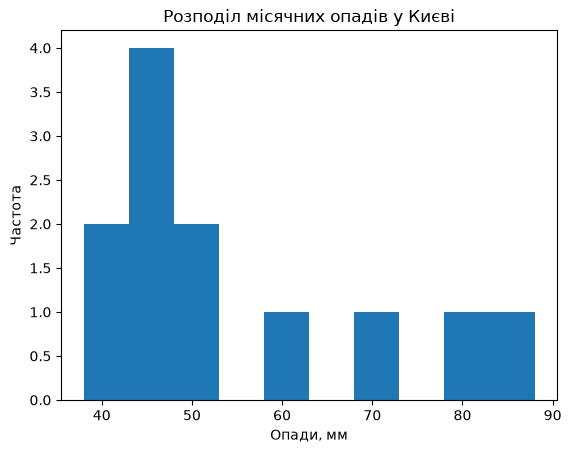

In [14]:
plt.hist(rain)
plt.xlabel("Опади, мм")
plt.ylabel("Частота")
plt.title("Розподіл місячних опадів у Києві")
plt.show()

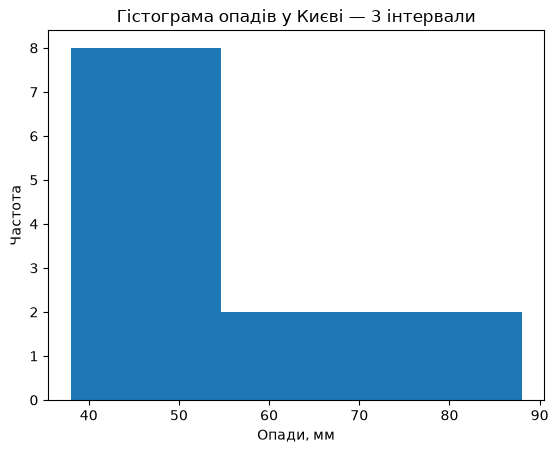

In [15]:
plt.hist(rain, bins=3)
plt.xlabel("Опади, мм")
plt.ylabel("Частота")
plt.title("Гістограма опадів у Києві — 3 інтервали")
plt.show()

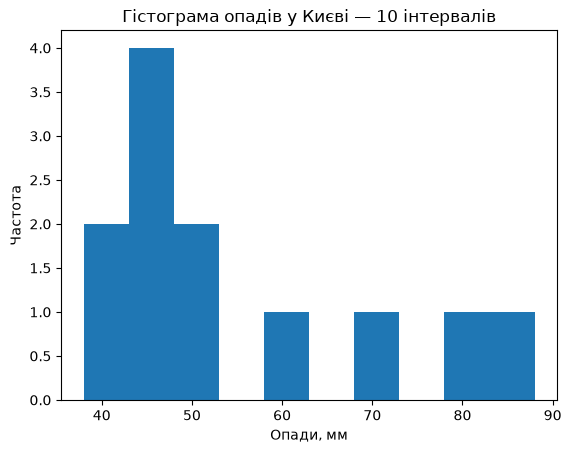

In [16]:
plt.hist(rain, bins=10)
plt.xlabel("Опади, мм")
plt.ylabel("Частота")
plt.title("Гістограма опадів у Києві — 10 інтервалів")
plt.show()

In [17]:
n = len(rain)

k_sqrt = round(np.sqrt(n))
k_sturges = round(1 + 3.322 * np.log10(n))

print("Кількість спостережень:", n)
print("За правилом √n:", k_sqrt)
print("За формулою Стерджеса:", k_sturges)

Кількість спостережень: 12
За правилом √n: 3
За формулою Стерджеса: 5


Найбільш наочно розподіл місячних опадів у Києві показує гістограма з 5 інтервалами. Варіант із 3 інтервалами занадто узагальнює дані, а 10 інтервалів для 12 спостережень дають надто фрагментовану картину. За правилом √n рекомендовано 3 інтервали, а за формулою Стерджеса — приблизно 5, тому для цього набору даних доцільно використати близько 5 інтервалів.

In [18]:
mean = rain.mean()
median = rain.median()
mode = rain.mode()

print("Середнє:", mean)
print("Медіана:", median)
print("Мода:", mode.iloc[0])

Середнє: 54.5
Медіана: 47.5
Мода: 47


In [19]:
q1 = rain.quantile(0.25)
q3 = rain.quantile(0.75)

print("Q1 =", q1)
print("Q3 =", q3)

Q1 = 43.75
Q3 = 62.5


### 5

Кількість опадів вимірюється за шкалою відношень, тому для неї можна використовувати середнє арифметичне, медіану та моду. Нульове значення має реальний зміст, а відношення між значеннями є змістовними.

Місто належить до номінальної шкали, тому для нього правильною мірою положення є лише мода. Обчислення середнього або медіани для назв міст не має змісту.



**1. Чому середнє арифметичне некоректне для номінальної змінної «місто», навіть якщо закодувати міста числами?**

Номінальна шкала містить лише назви категорій, між якими немає числових відстаней. Якщо закодувати міста числами, ці числа залишаються лише кодами, тому їх середнє арифметичне не має змісту.

**2. Чому «номер місяця» є неоднозначним випадком порівняно з явно порядковою або відношень?**

Номер місяця має природний порядок і однакові часові інтервали між сусідніми місяцями, але не має природного нуля. Тому його можна розглядати як інтервальну змінну, хоча для деяких задач номер місяця трактують як порядкову категорію.

**3. Чому для опадів, де майже всі 12 значень різні, потрібна гістограма з інтервалами, а не стовпчикова діаграма для кожного точного значення?**

Якщо будувати стовпчик для кожного точного значення, майже кожне значення матиме окремий стовпчик, що не дасть наочної картини розподілу. Гістограма об'єднує значення в інтервали та показує, як часто спостереження потрапляють у кожен діапазон.

**4. Що означає накопичена частота на межі третього інтервалу?**

Накопичена частота на межі третього інтервалу показує кількість місяців, у яких кількість опадів не перевищує верхню межу третього інтервалу. Для наших даних це 11 із 12 місяців, тобто 91,7%.